In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/processed/cleaned_dataset.csv")
os.makedirs("../outputs/figures", exist_ok=True)
sns.set_theme(style="whitegrid")

def save(name):
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/{name}.png", dpi=150)
    plt.show()

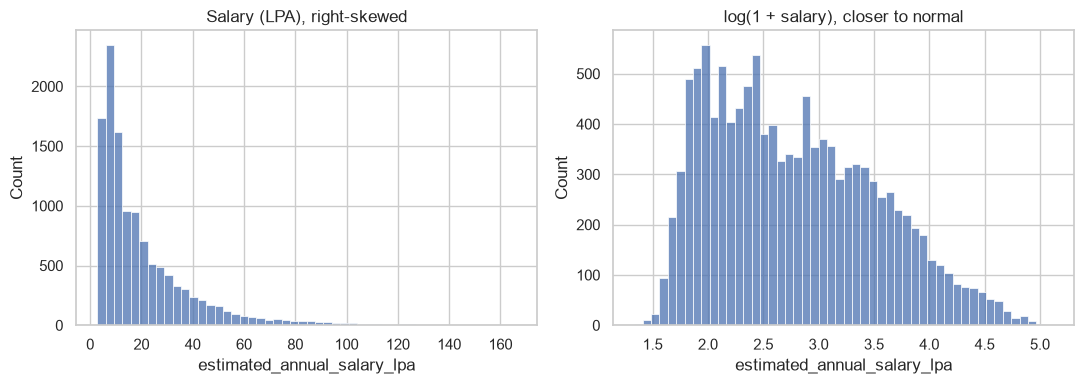

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["estimated_annual_salary_lpa"], bins=50, ax=ax[0])
ax[0].set_title("Salary (LPA), right-skewed")
sns.histplot(np.log1p(df["estimated_annual_salary_lpa"]), bins=50, ax=ax[1])
ax[1].set_title("log(1 + salary), closer to normal")
save("01_salary_distribution")

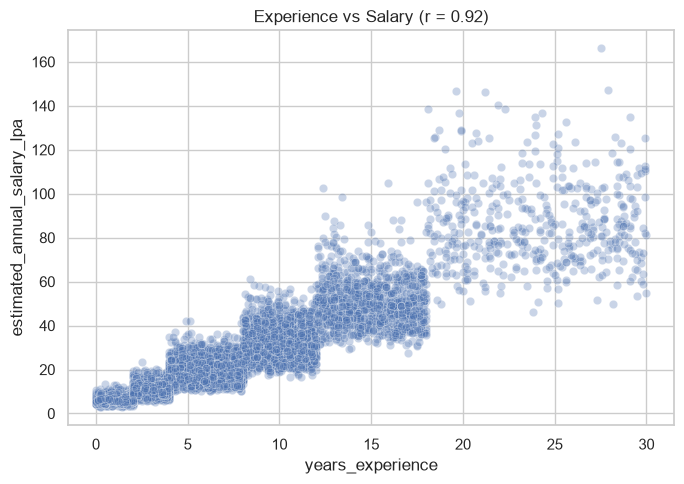

In [4]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="years_experience", y="estimated_annual_salary_lpa", alpha=0.3)
plt.title("Experience vs Salary (r = 0.92)")
save("02_experience_vs_salary")

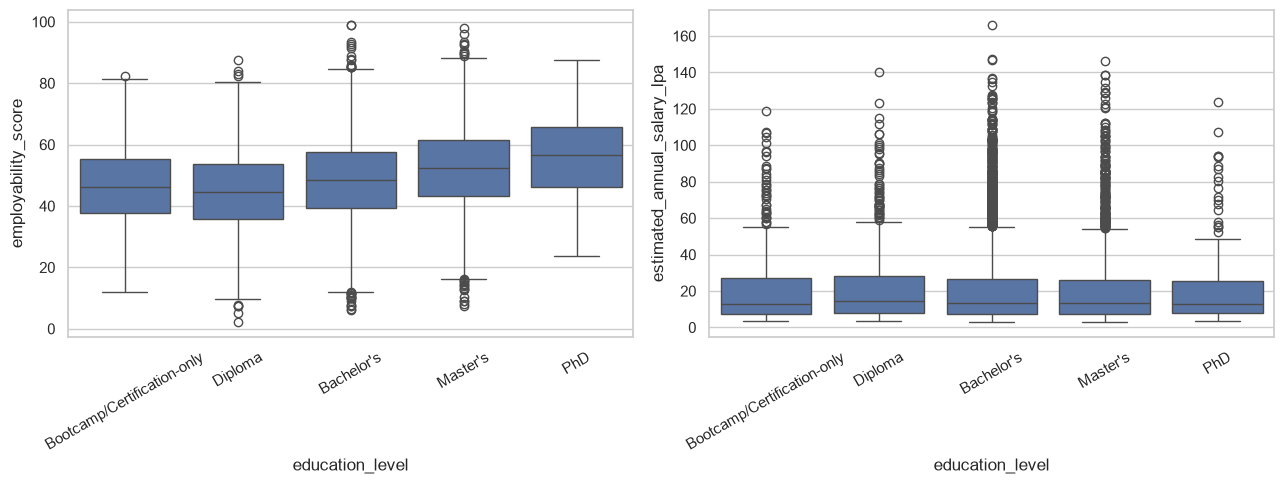

In [5]:
order = ["Bootcamp/Certification-only", "Diploma", "Bachelor's", "Master's", "PhD"]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="education_level", y="employability_score", order=order, ax=ax[0])
sns.boxplot(data=df, x="education_level", y="estimated_annual_salary_lpa", order=order, ax=ax[1])
for a in ax: a.tick_params(axis="x", rotation=30)
save("03_education")

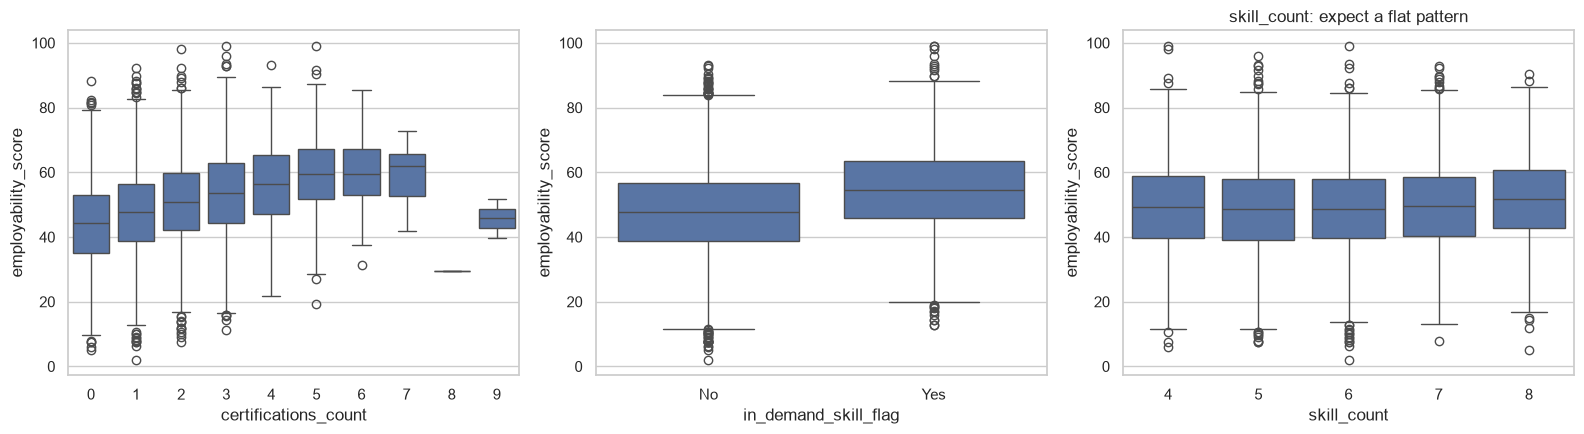

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="certifications_count", y="employability_score", ax=ax[0])
sns.boxplot(data=df, x="in_demand_skill_flag", y="employability_score", ax=ax[1])
sns.boxplot(data=df, x="skill_count", y="employability_score", ax=ax[2])
ax[2].set_title("skill_count: expect a flat pattern")
save("04_employability_drivers")

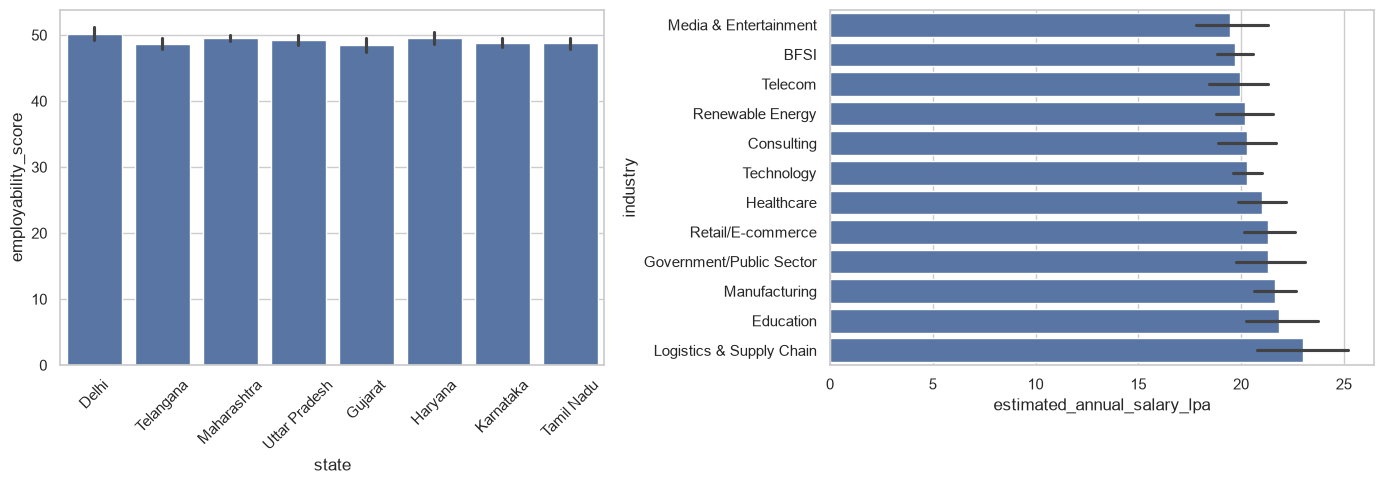

In [7]:
top_states = df["state"].value_counts().head(8).index
sub = df[df["state"].isin(top_states)]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=sub, x="state", y="employability_score", ax=ax[0])
sns.barplot(data=df, y="industry", x="estimated_annual_salary_lpa", ax=ax[1],
            order=df.groupby("industry")["estimated_annual_salary_lpa"].mean().sort_values().index)
ax[0].tick_params(axis="x", rotation=45)
save("05_location_industry")

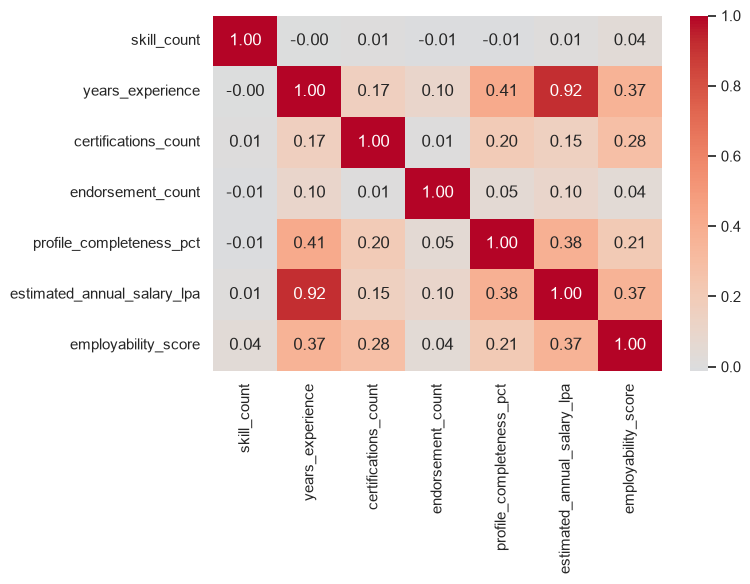

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
save("06_correlation")

                              in_demand_rate  employability     n
primary_skill_domain                                             
Core Engineering                         0.0          47.18   727
Content & Communication                  0.0          47.80   844
Digital Marketing                        0.0          48.14  1116
Finance/Accounting                       0.0          47.26   993
Sales & Business Development             0.0          46.87  1035
Product Management                       0.0          48.54   686
Operations & Supply Chain                0.0          46.76   732
Human Resources                          0.0          47.42   643
Software Engineering                     0.0          48.57  2241
UI/UX Design                             0.0          48.22   491
Cloud Computing                          1.0          54.83   660
AI/ML                                    1.0          54.62   529
Cybersecurity                            1.0          54.32   408
Data Scien

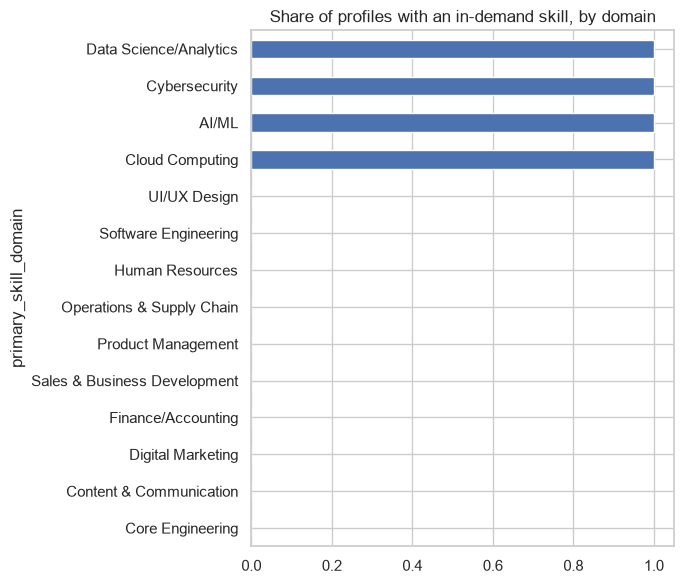

In [9]:
gap = df.groupby("primary_skill_domain").agg(
    in_demand_rate=("in_demand_skill_flag", lambda s: (s == "Yes").mean()),
    employability=("employability_score", "mean"),
    n=("profile_id", "count")).sort_values("in_demand_rate")
print(gap.round(2))
gap["in_demand_rate"].plot.barh(figsize=(7, 6), title="Share of profiles with an in-demand skill, by domain")
save("07_skill_gap_by_domain")

In [10]:
# 1. Confirm in_demand_flag is fully determined by domain
print(pd.crosstab(df["primary_skill_domain"], df["in_demand_skill_flag"]))

# 2. The gap table from Plot 7
print(gap.round(2))

# 3. What do top_skills actually look like within a domain?
skills = (df.assign(skill=df["top_skills"].str.split(";"))
            .explode("skill"))
skills["skill"] = skills["skill"].str.strip()
print(skills["skill"].nunique(), "unique skills")

top = (skills.groupby(["primary_skill_domain", "skill"]).size()
             .rename("n").reset_index())
for d in ["AI/ML", "Core Engineering"]:
    print("\n", d)
    print(top[top.primary_skill_domain == d].nlargest(8, "n")[["skill", "n"]])

in_demand_skill_flag            No  Yes
primary_skill_domain                   
AI/ML                            0  529
Cloud Computing                  0  660
Content & Communication        844    0
Core Engineering               727    0
Cybersecurity                    0  408
Data Science/Analytics           0  895
Digital Marketing             1116    0
Finance/Accounting             993    0
Human Resources                643    0
Operations & Supply Chain      732    0
Product Management             686    0
Sales & Business Development  1035    0
Software Engineering          2241    0
UI/UX Design                   491    0
                              in_demand_rate  employability     n
primary_skill_domain                                             
Core Engineering                         0.0          47.18   727
Content & Communication                  0.0          47.80   844
Digital Marketing                        0.0          48.14  1116
Finance/Accounting            

In [11]:
# 1. Build skill lists and check they match skill_count
df["skill_list"] = df["top_skills"].str.split(";").apply(lambda l: [s.strip() for s in l])
print("skill_count matches list length:", (df["skill_list"].str.len() == df["skill_count"]).mean())

# 2. Pool size per domain, then the gap score
pool = df.explode("skill_list").groupby("primary_skill_domain")["skill_list"].nunique()
print(pool.sort_values())
df["pool_size"] = df["primary_skill_domain"].map(pool)
df["skill_coverage"] = df["skill_count"] / df["pool_size"]
df["skill_gap_score"] = 1 - df["skill_coverage"]

# 3. Does it predict anything? Overall and within domain
print(df[["skill_gap_score", "employability_score", "estimated_annual_salary_lpa"]].corr().round(3))
print(df.groupby("primary_skill_domain")
        .apply(lambda g: g["skill_gap_score"].corr(g["employability_score"]))
        .round(3))

# 4. Does any individual skill matter? (employability relative to domain average)
df["resid"] = df["employability_score"] - df.groupby("primary_skill_domain")["employability_score"].transform("mean")
eff = (df.explode("skill_list")
         .groupby(["primary_skill_domain", "skill_list"])["resid"].mean().round(2))
print(eff.sort_values().head(5))
print(eff.sort_values().tail(5))

skill_count matches list length: 1.0
primary_skill_domain
Core Engineering                 5
Content & Communication          5
Operations & Supply Chain        5
Human Resources                  6
UI/UX Design                     6
Sales & Business Development     6
Digital Marketing                7
Finance/Accounting               7
Product Management               7
Cybersecurity                    8
Cloud Computing                  9
AI/ML                            9
Data Science/Analytics           9
Software Engineering            11
Name: skill_list, dtype: int64
                             skill_gap_score  employability_score  \
skill_gap_score                        1.000                0.079   
employability_score                    0.079                1.000   
estimated_annual_salary_lpa            0.029                0.367   

                             estimated_annual_salary_lpa  
skill_gap_score                                    0.029  
employability_score       